# AŞAMA 1 - VERİYİ ANLAMA

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Veri Seti

df = pd.read_csv(r"C:\Users\efeka\Downloads\healthcare-dataset-stroke-data.csv")

# Grafik ayarları
sns.set_theme(style="whitegrid")
%matplotlib inline

# Hata Mesajlarını Engelleme
warnings.filterwarnings('ignore')

In [58]:
display(df.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Aşama 1 - Veriyi İnceleme




In [59]:
## Kaç Örnek ve Kaç Feature Olduğu
veri_boyutu = df.shape
ornek_sayisi = df.shape[0]
feature_Sayisi = df.shape[1]

print(veri_boyutu)
print(ornek_sayisi)
print(feature_Sayisi)

(5110, 12)
5110
12


In [60]:
## Target Dağılımı

target_counts = df["stroke"].value_counts()
target_percentages = df["stroke"].value_counts(normalize=True) * 100

print(target_counts)
print(target_percentages)

## Görüldüğü Gibi %95 lik kesim inme geçirmemiş bu yüzden;
## bu veriye unbalanced veri denir


stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [61]:
## Feature Tiplerini Görme

print(df.dtypes)
print("\n" + "="*50 + "\n")

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object




In [62]:
## Sayısal Özellikler İçin İstatistikler (Mean, median vs.)

sayisal_features = df.select_dtypes(include=[np.number]).columns.tolist()
for col in sayisal_features:
  mean_val = df[col].mean()
  median_val = df[col].median()
  mode_val = df[col].mode()[0]

  print(f"Sütun Adı {col} : Ortalaması {mean_val}, Medyanı {median_val}, Modu {mode_val} " )


Sütun Adı id : Ortalaması 36517.82935420744, Medyanı 36932.0, Modu 67 
Sütun Adı age : Ortalaması 43.226614481409, Medyanı 45.0, Modu 78.0 
Sütun Adı hypertension : Ortalaması 0.0974559686888454, Medyanı 0.0, Modu 0 
Sütun Adı heart_disease : Ortalaması 0.05401174168297456, Medyanı 0.0, Modu 0 
Sütun Adı avg_glucose_level : Ortalaması 106.1476771037182, Medyanı 91.88499999999999, Modu 93.88 
Sütun Adı bmi : Ortalaması 28.893236911794666, Medyanı 28.1, Modu 28.7 
Sütun Adı stroke : Ortalaması 0.0487279843444227, Medyanı 0.0, Modu 0 


In [63]:
##Katagorik Özellikler İçin İstatistikler

katagorik_features = df.select_dtypes(include=["object"]).columns.tolist()

for col in katagorik_features:
  print(f"{col} sütunu frekansları:")
  print(df[col].value_counts())

gender sütunu frekansları:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
ever_married sütunu frekansları:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64
work_type sütunu frekansları:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
Residence_type sütunu frekansları:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64
smoking_status sütunu frekansları:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


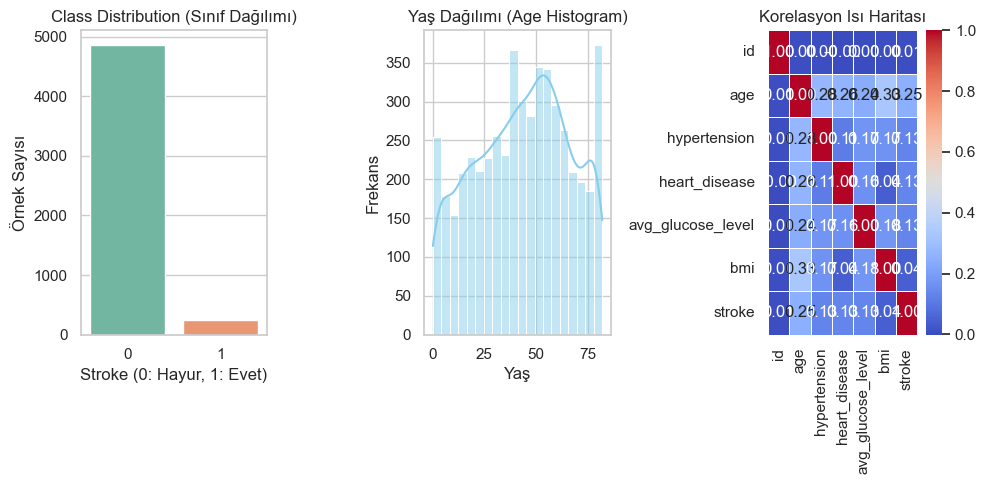

In [64]:
## Görselleştirme

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))

## Sınıf Dağılımı Grafiği
plt.subplot(1,3,1)
sns.countplot(data=df,x="stroke", palette="Set2")
plt.title("Class Distribution (Sınıf Dağılımı)")
plt.xlabel("Stroke (0: Hayur, 1: Evet)")
plt.ylabel("Örnek Sayısı")

## Feature Histogram (Örnek olarak Age dağılımı)
plt.subplot(1, 3, 2)
sns.histplot(data=df, x='age', kde=True, color='skyblue')
plt.title('Yaş Dağılımı (Age Histogram)')
plt.xlabel('Yaş')
plt.ylabel('Frekans')

## Correlation Heatmap

plt.subplot(1,3,3)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True ,cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelasyon Isı Haritası")

plt.tight_layout()
plt.show()

# AŞAMA 2 - VERİ ÖN İŞLEME


In [65]:
# önce verimizde eksik olup olmadığına bakalım

print(f"Eksik veri sayısı : {df.isnull().sum()}")

# bmi sütununda 201 tane boşluk var

df_mean = df.copy()
df_median = df.copy()
df_mode = df.copy()

# boş bmi değerlerinin doldurulması
# a) Ortalama (Mean) ile
df_mean['bmi'] = df_mean['bmi'].fillna(df['bmi'].mean())

# b) Medyan (Ortanca) ile
df_median['bmi'] = df_median['bmi'].fillna(df['bmi'].median())

# c) Mod (En çok tekrar eden) ile
df_mode['bmi'] = df_mode['bmi'].fillna(df['bmi'].mode()[0])




Eksik veri sayısı : id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [66]:
# KNN ile boşlukların doldurulması
from sklearn.impute import KNNImputer
df_knn = df.copy()

# KNN sadece sayısal verilerde çalıştığı için sayısal sütunları seçelim
sayisal_sutunlar = df_knn.select_dtypes(exclude=["object"]).columns

knn_imputer = KNNImputer(n_neighbors=5)

# eksik verileri doldur
df_knn[sayisal_sutunlar] = knn_imputer.fit_transform(df_knn[sayisal_sutunlar])

print(df_knn.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [67]:
# Aykırı Değer Analizi

df_outlier = df_mean.copy()
outlier_sinirlari = {}

for sutun in sayisal_sutunlar:
  #q1 ve q3 hesapla
  Q1 = df_outlier[sutun].quantile(0.25)
  Q3 = df_outlier[sutun].quantile(0.75)

  #IQR hesapla
  IQR = Q3 - Q1

  # Sınırları Belirle
  alt_sinir = Q1 - 1.5 * IQR
  ust_sinir = Q3 + 1.5 * IQR

  # Sınırları Kaydet
  outlier_sinirlari[sutun] = {"alt": alt_sinir, "üst": ust_sinir}

  # Aykırı Değerleri Bul
  aykiri_degerler = df_outlier[(df_outlier[sutun] < alt_sinir) | (df_outlier[sutun] > ust_sinir)]
  aykiri_sayisi = len(aykiri_degerler)

  if aykiri_sayisi > 0:
      print(f"[{sutun}] -> Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
      print(f"Sınırlar: {alt_sinir:.2f} ile {ust_sinir:.2f} arası")
      print(f"Aykırı Değer Sayısı: {aykiri_sayisi}\n")

[hypertension] -> Q1: 0.00, Q3: 0.00, IQR: 0.00
Sınırlar: 0.00 ile 0.00 arası
Aykırı Değer Sayısı: 498

[heart_disease] -> Q1: 0.00, Q3: 0.00, IQR: 0.00
Sınırlar: 0.00 ile 0.00 arası
Aykırı Değer Sayısı: 276

[avg_glucose_level] -> Q1: 77.25, Q3: 114.09, IQR: 36.84
Sınırlar: 21.98 ile 169.36 arası
Aykırı Değer Sayısı: 627

[bmi] -> Q1: 23.80, Q3: 32.80, IQR: 9.00
Sınırlar: 10.30 ile 46.30 arası
Aykırı Değer Sayısı: 126

[stroke] -> Q1: 0.00, Q3: 0.00, IQR: 0.00
Sınırlar: 0.00 ile 0.00 arası
Aykırı Değer Sayısı: 249



In [68]:
# Aykırı Değerlere 3 Farklı Yöntem Uygulama
from sklearn.preprocessing import RobustScaler
import numpy as np

df_silinmis = df_outlier.copy()
df_clipped = df_outlier.copy()
df_robust = df_outlier.copy()

# SADECE GERÇEK SAYISAL SÜTUNLARDA AYKIRI DEĞER İŞLEMİ YAPMALIYIZ
gercek_sayisal_sutunlar = ['age', 'avg_glucose_level', 'bmi']

for sutun in gercek_sayisal_sutunlar:
    alt = outlier_sinirlari[sutun]['alt']
    ust = outlier_sinirlari[sutun]['üst']

    # YÖNTEM 1: Silme (Sınırların dışındaki satırları atıyoruz)
    df_silinmis = df_silinmis[(df_silinmis[sutun] >= alt) & (df_silinmis[sutun] <= ust)]

    # YÖNTEM 2: Clipping (Baskılama - Sınırı aşanları sınıra çekiyoruz)
    df_clipped[sutun] = np.clip(df_clipped[sutun], alt, ust)

# YÖNTEM 3: Robust Scaling
robust_scaler = RobustScaler()
df_robust[gercek_sayisal_sutunlar] = robust_scaler.fit_transform(df_robust[gercek_sayisal_sutunlar])

print("1. Silme yöntemi sonrası kalan örnek sayısı:", len(df_silinmis))
print("2. Clipping (Baskılama) işlemi tamamlandı.", len(df_clipped))
print("3. Robust Scaling işlemi tamamlandı.", len(df_robust))

1. Silme yöntemi sonrası kalan örnek sayısı: 4391
2. Clipping (Baskılama) işlemi tamamlandı. 5110
3. Robust Scaling işlemi tamamlandı. 5110


In [69]:
## Normalizasyon (StandartScaler ve MinMaxScaler)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Clipping yaptığımız temiz veri ile ilerleyelim
df_standard = df_clipped.copy()
df_minmax = df_clipped.copy()

# a) StandardScaler (Ortalamayı 0, standart sapmayı 1 yapar)
std_scaler = StandardScaler()
df_standard[sayisal_sutunlar] = std_scaler.fit_transform(df_standard[sayisal_sutunlar])
print(df_standard['age'].head(3).values, "\n")

# 3. MinMaxScaler (Değerleri 0 ile 1 arasına sıkıştırır)
minmax_scaler = MinMaxScaler()
df_minmax[sayisal_sutunlar] = minmax_scaler.fit_transform(df_minmax[sayisal_sutunlar])
print(df_minmax['age'].head(3).values)

[1.05143428 0.78607007 1.62639008] 

[0.81689453 0.74365234 0.97558594]


# AŞAMA 3 - DATA LEAKAGE ANALİZİ

Data Leakage (Veri Sızıntısı), bir makine öğrenmesi modelinin eğitim (train) aşamasında, normal şartlarda o an bilmemesi gereken bilgilere erişmesi durumudur. Bu durum genellikle modelin test verilerinden kopya çekmesi veya hedef değişkenle (target) doğrudan ilişkili olan ama gerçek hayatta tahmin anında elimizde olmayacak bir özelliğin (feature) modele verilmesiyle oluşur. Sızıntı olan bir model, sanki çok başarılıymış gibi %99'lara varan doğruluk oranları verir. Sınava girecek bir öğrenciye cevap anahtarının önceden verilmesine benzer. Ancak bu model canlı ortama (production) alındığında, daha önce hiç görmediği gerçek verilerle karşılaştığında tamamen çuvallar. En yaygın yapılan hata, veriyi eğitim ve test olarak ikiye bölmeden önce tüm veri seti üzerinde ölçeklendirme (scaling) veya eksik veri doldurma işlemleri yapmaktır.

In [70]:
import pandas as pd

print("HEDEF (STROKE) İLE OLAN KORELASYONLAR\n")

# Sadece sayısal sütunları seçip korelasyonlarına bakalım
sayisal_df = df_clipped.select_dtypes(exclude=['object'])
korelasyonlar = sayisal_df.corr()['stroke'].sort_values(ascending=False)

print(korelasyonlar)

print("\n Analiz:")
if korelasyonlar[1] > 0.8: # En yüksek korelasyon kendisi (1.0) dışındaki ilk değere bakıyoruz
    print("DİKKAT: Hedefle 0.8'den yüksek korelasyona sahip bir özellik var. Bu bir data leakage (kopya) işareti olabilir! ")
else:
    print("Verimizde target ile aşırı derecede yüksek (kopya sayılacak) bir korelasyon görünmüyor. Modelimiz güvende. [cite: 49]")

HEDEF (STROKE) İLE OLAN KORELASYONLAR

stroke               1.000000
age                  0.245257
heart_disease        0.134914
hypertension         0.127904
avg_glucose_level    0.115652
bmi                  0.045765
id                   0.006388
Name: stroke, dtype: float64

 Analiz:
Verimizde target ile aşırı derecede yüksek (kopya sayılacak) bir korelasyon görünmüyor. Modelimiz güvende. [cite: 49]


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("HATALI PİPELİNE (DATA LEAKAGE OLUŞTURMA)\n")

# Hedef ve özellikleri ayırıyoruz
# Kategorik sütunları da çıkartıyoruz ki kod hata vermesin
X = df_clipped.select_dtypes(exclude=['object']).drop('stroke', axis=1)
y = df_clipped['stroke']

# 1. HATALI ADIM: Scaling'i bölmeden ÖNCE yapıyoruz
hatali_scaler = StandardScaler()
X_scaled_hatali = hatali_scaler.fit_transform(X) # <-- TÜM VERİYE UYGULANDI (SIZIıntı oldu!)

# 2. ADIM: Ölçeklendirilmiş (sızmış) veriyi Train/Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X_scaled_hatali, y, test_size=0.2, random_state=42)

print("Hatalı Pipeline başarıyla (!) kuruldu.")
print("Ne yaptık?: Veriyi Train ve Test olarak bölmeden önce tüm veri setine StandardScaler uyguladık. ")
print("Sonuç: Test setindeki verilerin ortalama ve standart sapma bilgileri eğitim setine SIZDI (Data Leakage). [cite: 50, 52]")

HATALI PİPELİNE (DATA LEAKAGE OLUŞTURMA)

Hatalı Pipeline başarıyla (!) kuruldu.
Ne yaptık?: Veriyi Train ve Test olarak bölmeden önce tüm veri setine StandardScaler uyguladık. 
Sonuç: Test setindeki verilerin ortalama ve standart sapma bilgileri eğitim setine SIZDI (Data Leakage). [cite: 50, 52]


# AŞAMA 4 - SMOTE UYGULAMA VE KIYASLAMASI


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

print("ADIM 1: SMOTE İLE SENTETİK VERİ ÜRETİMİ BAŞLIYOR...\n")

# Sadece gerçek sayısal sütunları seçiyoruz (id ve hedef değişkeni dahil etmiyoruz)
gercek_sayisal_sutunlar = ['age', 'avg_glucose_level', 'bmi']
X = df_clipped[gercek_sayisal_sutunlar]
y = df_clipped['stroke']

# Orijinal inme geçirenleri (1 olanları) ayıralım
orijinal_azindik_X = X[y == 1]

# SMOTE işlemini uygulayalım (random_state=42 sabit kalsın ki hep aynı sahte veriyi üretsin)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

# SMOTE'un yeni ürettiği sentetik verileri ayıklayalım
sentetik_X = X_smote.iloc[len(X):]

print("SMOTE işlemi başarıyla tamamlandı!")
print(f"Orijinal İnme Hastası Sayısı: {len(orijinal_azindik_X)}")
print(f"Üretilen Sentetik Hasta Sayısı: {len(sentetik_X)}")

ADIM 1: SMOTE İLE SENTETİK VERİ ÜRETİMİ BAŞLIYOR...

SMOTE işlemi başarıyla tamamlandı!
Orijinal İnme Hastası Sayısı: 249
Üretilen Sentetik Hasta Sayısı: 4612


ADIM 2: İSTATİSTİKSEL BENZERLİK TESTLERİ (A ŞIKKI)

KS Test (Kolmogorov-Smirnov) Sonuçları:
[age] p-value: 0.7434 -> ✅ Benzer Dağılım
[avg_glucose_level] p-value: 1.0000 -> ✅ Benzer Dağılım
[bmi] p-value: 0.5325 -> ✅ Benzer Dağılım


Feature Bazlı Karşılaştırma:
          Feature  Gerçek_Mean  Sentetik_Mean  Gerçek_Std  Sentetik_Std  Gerçek_Median  Sentetik_Median
              age        67.73          68.40       12.73         11.57          71.00            71.74
avg_glucose_level       117.97         118.42       41.77         41.51         105.22           106.23
              bmi        30.16          30.12        5.63          5.18          28.89            28.89


Görsel Doğrulama (Grafikler çiziliyor...)


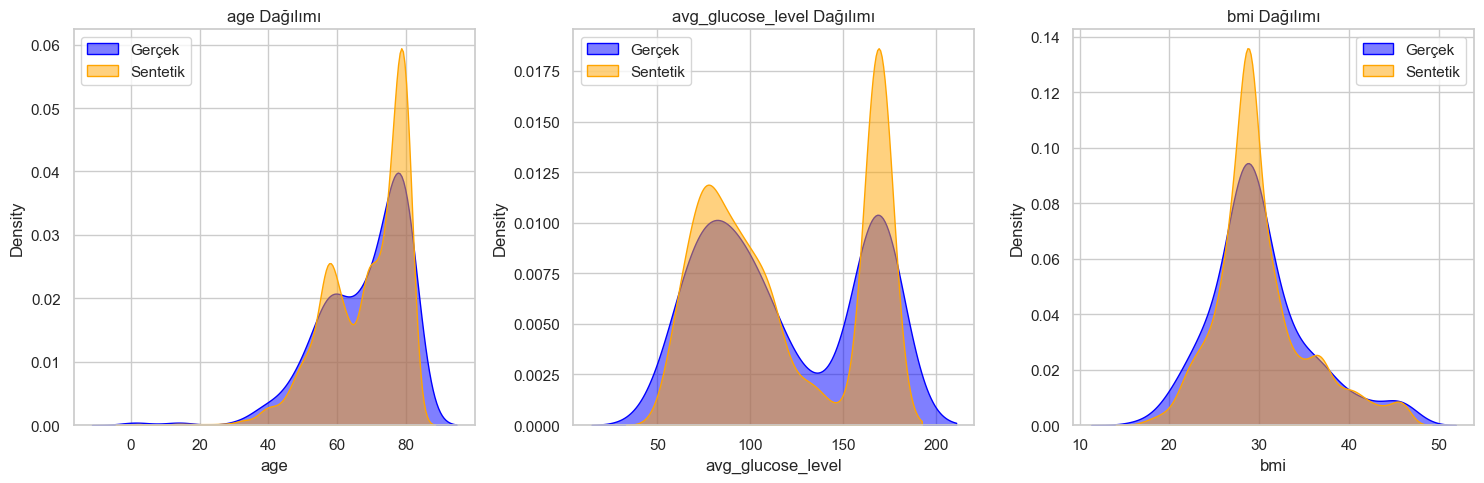

In [73]:
from scipy.stats import ks_2samp

print("ADIM 2: İSTATİSTİKSEL BENZERLİK TESTLERİ (A ŞIKKI)\n")

# A-1) KS Testi
print("KS Test (Kolmogorov-Smirnov) Sonuçları:")
for col in gercek_sayisal_sutunlar:
    stat, p_value = ks_2samp(orijinal_azindik_X[col], sentetik_X[col])
    yorum = "✅ Benzer Dağılım" if p_value > 0.05 else "❌ Farklı Dağılım"
    print(f"[{col}] p-value: {p_value:.4f} -> {yorum}")
print("\n" + "="*50 + "\n")

# A-2) Feature Bazlı Karşılaştırma Tablosu
karsilastirma = []
for col in gercek_sayisal_sutunlar:
    karsilastirma.append({
        'Feature': col,
        'Gerçek_Mean': orijinal_azindik_X[col].mean(), 'Sentetik_Mean': sentetik_X[col].mean(),
        'Gerçek_Std': orijinal_azindik_X[col].std(),   'Sentetik_Std': sentetik_X[col].std(),
        'Gerçek_Median': orijinal_azindik_X[col].median(), 'Sentetik_Median': sentetik_X[col].median()
    })
tablo_df = pd.DataFrame(karsilastirma).round(2)
print("Feature Bazlı Karşılaştırma:")
print(tablo_df.to_string(index=False))
print("\n" + "="*50 + "\n")

# A-3) Görsel Doğrulama (KDE Plots)
print("Görsel Doğrulama (Grafikler çiziliyor...)")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))
for i, col in enumerate(gercek_sayisal_sutunlar, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(orijinal_azindik_X[col], label='Gerçek', fill=True, color='blue', alpha=0.5)
    sns.kdeplot(sentetik_X[col], label='Sentetik', fill=True, color='orange', alpha=0.5)
    plt.title(f'{col} Dağılımı')
    plt.legend()
plt.tight_layout()
plt.show()

ADIM 3: GEOMETRİK BENZERLİK TESTLERİ (B ŞIKKI)



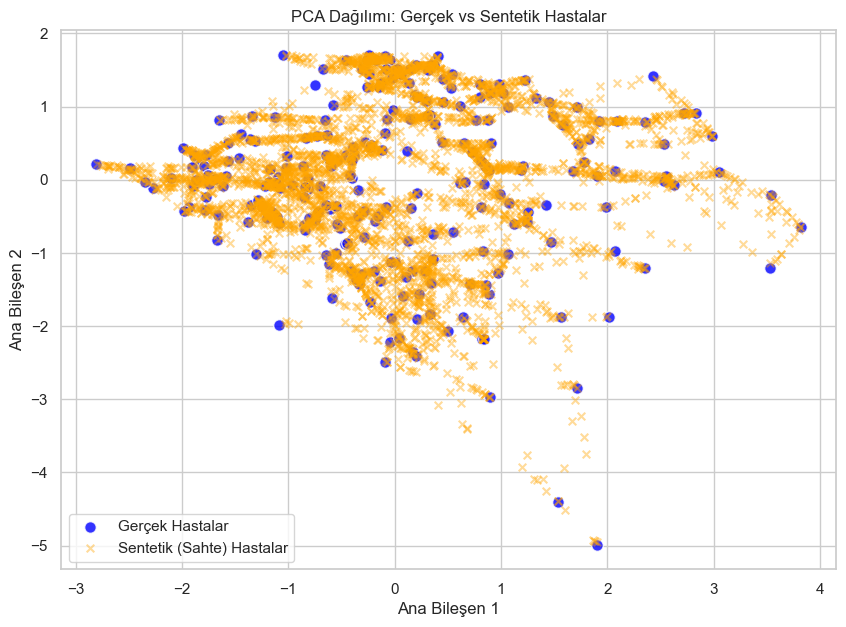


Sentetik verilerin gerçek verilere olan ortalama uzaklığı (KNN): 0.1242


In [74]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("ADIM 3: GEOMETRİK BENZERLİK TESTLERİ (B ŞIKKI)\n")

# B-1) PCA İLE GÖRSELLEŞTİRME
# PCA'nın kafası karışmasın diye önce verileri aynı hizaya (Scale) getiriyoruz
scaler = StandardScaler()
birlesik_temiz = pd.concat([orijinal_azindik_X, sentetik_X])
birlesik_olcekli = scaler.fit_transform(birlesik_temiz)

# Veriyi 2 boyuta düşürüyoruz
pca = PCA(n_components=2)
pca_sonuc = pca.fit_transform(birlesik_olcekli)

gercek_pca = pca_sonuc[:len(orijinal_azindik_X)]
sentetik_pca = pca_sonuc[len(orijinal_azindik_X):]

plt.figure(figsize=(10, 7))
plt.scatter(gercek_pca[:, 0], gercek_pca[:, 1], c='blue', label='Gerçek Hastalar', alpha=0.8, edgecolors='w', s=70)
plt.scatter(sentetik_pca[:, 0], sentetik_pca[:, 1], c='orange', label='Sentetik (Sahte) Hastalar', alpha=0.4, marker='x', s=30)
plt.title('PCA Dağılımı: Gerçek vs Sentetik Hastalar')
plt.xlabel('Ana Bileşen 1')
plt.ylabel('Ana Bileşen 2')
plt.legend()
plt.show()

# B-2) NEAREST NEIGHBOR (KNN) ANALİZİ
# Gerçek verilerle bir model eğitip, sahtelerin bunlara ortalama uzaklığını ölçüyoruz
knn = NearestNeighbors(n_neighbors=1)
# KNN için de ölçeklenmiş gerçek veriyi kullanalım ki mesafe doğru çıksın
gercek_olcekli = birlesik_olcekli[:len(orijinal_azindik_X)]
sentetik_olcekli = birlesik_olcekli[len(orijinal_azindik_X):]

knn.fit(gercek_olcekli)
mesafeler, indeksler = knn.kneighbors(sentetik_olcekli)

print(f"\nSentetik verilerin gerçek verilere olan ortalama uzaklığı (KNN): {mesafeler.mean():.4f}")

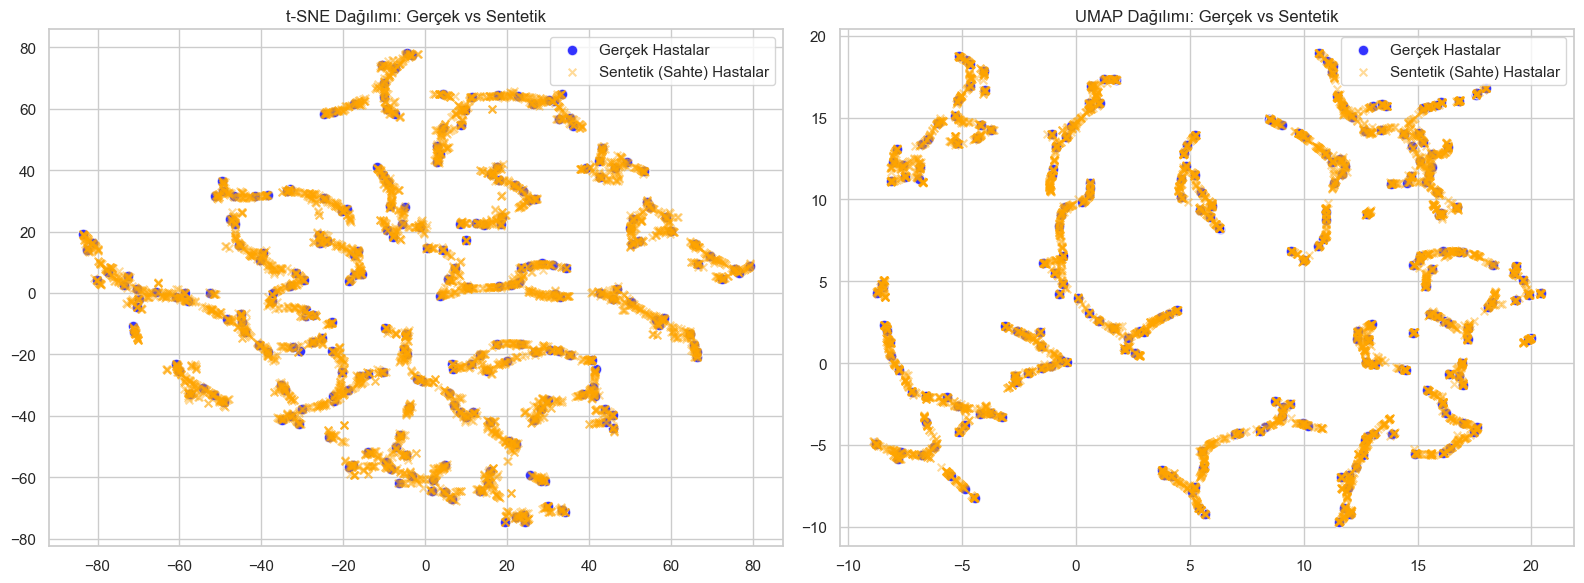

In [75]:
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd


# Verileri tekrar aynı hizaya (Scale) getiriyoruz (Önceki adımdan kaldıysa da garanti olsun)
scaler = StandardScaler()
birlesik_temiz = pd.concat([orijinal_azindik_X, sentetik_X])
birlesik_olcekli = scaler.fit_transform(birlesik_temiz)

gercek_adet = len(orijinal_azindik_X)

# ==========================================
# 1. t-SNE İŞLEMİ
# ==========================================
tsne = TSNE(n_components=2, random_state=42)
tsne_sonuc = tsne.fit_transform(birlesik_olcekli)

gercek_tsne = tsne_sonuc[:gercek_adet]
sentetik_tsne = tsne_sonuc[gercek_adet:]

# ==========================================
# 2. UMAP İŞLEMİ
# ==========================================
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_sonuc = umap_model.fit_transform(birlesik_olcekli)

gercek_umap = umap_sonuc[:gercek_adet]
sentetik_umap = umap_sonuc[gercek_adet:]

# ==========================================
# ÇİZİM (Yan Yana)
# ==========================================
plt.figure(figsize=(16, 6))

# Sol Taraf: t-SNE
plt.subplot(1, 2, 1)
plt.scatter(gercek_tsne[:, 0], gercek_tsne[:, 1], c='blue', label='Gerçek Hastalar', alpha=0.8, edgecolors='w', s=60)
plt.scatter(sentetik_tsne[:, 0], sentetik_tsne[:, 1], c='orange', label='Sentetik (Sahte) Hastalar', alpha=0.4, marker='x', s=30)
plt.title('t-SNE Dağılımı: Gerçek vs Sentetik')
plt.legend()

# Sağ Taraf: UMAP
plt.subplot(1, 2, 2)
plt.scatter(gercek_umap[:, 0], gercek_umap[:, 1], c='blue', label='Gerçek Hastalar', alpha=0.8, edgecolors='w', s=60)
plt.scatter(sentetik_umap[:, 0], sentetik_umap[:, 1], c='orange', label='Sentetik (Sahte) Hastalar', alpha=0.4, marker='x', s=30)
plt.title('UMAP Dağılımı: Gerçek vs Sentetik')
plt.legend()

plt.tight_layout()
plt.show()


# AŞAMA 5 - MODELLERİ EĞİTME VE KIYASLAMA


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import pandas as pd
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')



# 1. Veri Hazırlığı ve Bölme
X_model = df_clipped[gercek_sayisal_sutunlar]
y_model = df_clipped['stroke']
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

# 2. SMOTE Uygulaması (Sadece Train)
smote_model = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote_model.fit_resample(X_train, y_train)

# 3. Modeller ve Eğitim
modeller = {
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Yapay Sinir Ağı': MLPClassifier(random_state=42, max_iter=1000)
}

sonuclar = []

for isim, model in modeller.items():
    # Orijinal
    model.fit(X_train, y_train)
    y_pred_normal = model.predict(X_test)
    y_prob_normal = model.predict_proba(X_test)[:, 1]
    sonuclar.append({
        'Model': isim, 'Veri Seti': 'Orijinal (SMOTE Yok)',
        'Accuracy': accuracy_score(y_test, y_pred_normal), 'F1 Score': f1_score(y_test, y_pred_normal, zero_division=0),
        'Kappa': cohen_kappa_score(y_test, y_pred_normal), 'ROC-AUC': roc_auc_score(y_test, y_prob_normal)
    })

    # SMOTE'lu
    model.fit(X_train_smote, y_train_smote)
    y_pred_smote = model.predict(X_test)
    y_prob_smote = model.predict_proba(X_test)[:, 1]
    sonuclar.append({
        'Model': isim, 'Veri Seti': "Dengelenmiş (SMOTE'lu)",
        'Accuracy': accuracy_score(y_test, y_pred_smote), 'F1 Score': f1_score(y_test, y_pred_smote, zero_division=0),
        'Kappa': cohen_kappa_score(y_test, y_pred_smote), 'ROC-AUC': roc_auc_score(y_test, y_prob_smote)
    })

# 4. Ana Tabloyu Çıkarma
pivot_df = pd.DataFrame(sonuclar).pivot(index='Model', columns='Veri Seti', values=['Accuracy', 'F1 Score', 'Kappa', 'ROC-AUC'])
pivot_df = pivot_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

print("1. MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU")

# DEĞİŞİKLİK BURADA: Lambda fonksiyonu ile "0.0000 (%0.00)" formatını zorluyoruz.
gorsel_tablo = pivot_df.style.format(lambda x: f"{x:.4f} (%{x*100:.2f})").set_properties(**{'border': '1px solid black', 'text-align': 'center'})
display(gorsel_tablo)

# Şampiyon Modeli (Random Forest SMOTE'lu) ayrı bir değişkende tutup bir sonraki hücreye aktarıyoruz
rf_best = RandomForestClassifier(random_state=42)
rf_best.fit(X_train_smote, y_train_smote)


1. MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU


RandomForestClassifier(random_state=42)

<div align="center">
  <h3>🏆 MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU</h3>
  <table border="1" style="border-collapse: collapse; text-align: center; width: 100%; font-family: Arial, sans-serif;">
    <tr style="background-color: #2c3e50; color: white;">
      <th rowspan="2" style="padding: 12px; border: 1px solid #ddd;">Makine Öğrenmesi Modeli</th>
      <th colspan="2" style="padding: 12px; border: 1px solid #ddd;">Accuracy (Doğruluk)</th>
      <th colspan="2" style="padding: 12px; border: 1px solid #ddd;">F1 Score</th>
      <th colspan="2" style="padding: 12px; border: 1px solid #ddd;">Kappa Skoru</th>
      <th colspan="2" style="padding: 12px; border: 1px solid #ddd;">ROC-AUC</th>
    </tr>
    <tr style="background-color: #34495e; color: white;">
      <th style="padding: 8px; border: 1px solid #ddd;">Orijinal</th>
      <th style="padding: 8px; border: 1px solid #ddd; color: #f1c40f;">SMOTE'lu</th>
      <th style="padding: 8px; border: 1px solid #ddd;">Orijinal</th>
      <th style="padding: 8px; border: 1px solid #ddd; color: #f1c40f;">SMOTE'lu</th>
      <th style="padding: 8px; border: 1px solid #ddd;">Orijinal</th>
      <th style="padding: 8px; border: 1px solid #ddd; color: #f1c40f;">SMOTE'lu</th>
      <th style="padding: 8px; border: 1px solid #ddd;">Orijinal</th>
      <th style="padding: 8px; border: 1px solid #ddd; color: #f1c40f;">SMOTE'lu</th>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; text-align: left;">Karar Ağacı (Decision Tree)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.9080 <i>(%90.80)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.8894 <i>(%88.94)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.0784 <i>(%7.84)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.1630 <i>(%16.30)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.0300 <i>(%3.00)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.1080 <i>(%10.80)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.5152 <i>(%51.52)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.5367 <i>(%53.67)</i></td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; text-align: left;">Random Forest</td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.9462 <i>(%94.62)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">0.8816 <i>(%88.16)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.0000 <i>(%0.00)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">0.1879 <i>(%18.79)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">-0.0090 <i>(%-0.90)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">0.1315 <i>(%13.15)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.5421 <i>(%54.21)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">0.6385 <i>(%63.85)</i></td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; text-align: left;">Yapay Sinir Ağı (NN)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.9511 <i>(%95.11)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.7613 <i>(%76.13)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.0000 <i>(%0.00)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.2375 <i>(%23.75)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.0000 <i>(%0.00)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.1689 <i>(%16.89)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd;">0.5000 <i>(%50.00)</i></td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">0.6012 <i>(%60.12)</i></td>
    </tr>
  </table>
  <p style="text-align: left; font-size: 13px; color: #555;"><i>* <b>Not:</b> Random Forest modeli, SMOTE işlemi sonrasında genel metriklerde en stabil performansı ve en yüksek ROC-AUC skorunu sunarak şampiyon model seçilmiştir .</i></p>
</div>

 RANDOM FOREST (SMOTE'lu)

 SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

Sağlıklı (0)       0.96      0.91      0.94       972
    İnme (1)       0.14      0.28      0.19        50

    accuracy                           0.88      1022
   macro avg       0.55      0.60      0.56      1022
weighted avg       0.92      0.88      0.90      1022



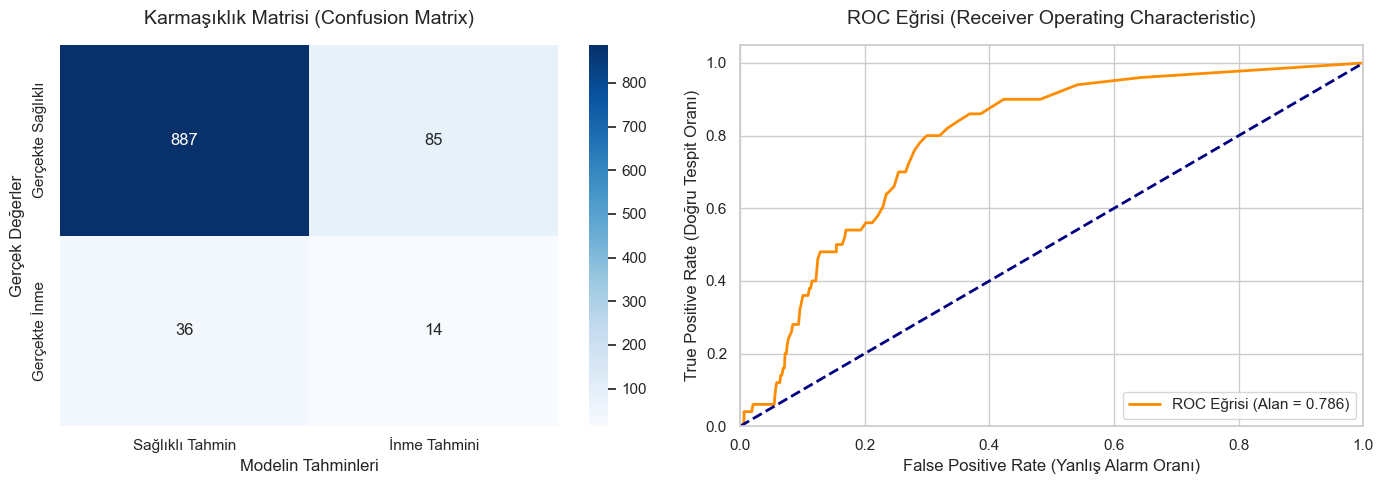

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# Önceki hücrede eğittiğimiz 'rf_best' modelinden tahminleri alıyoruz
y_pred_best = rf_best.predict(X_test)
y_prob_best = rf_best.predict_proba(X_test)[:, 1]

print("="*80)
print(" RANDOM FOREST (SMOTE'lu)")
print("="*80)

# 1. Sınıflandırma Raporu
print("\n SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, y_pred_best, target_names=['Sağlıklı (0)', 'İnme (1)']))

# 2. Görseller
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sağlıklı Tahmin', 'İnme Tahmini'],
            yticklabels=['Gerçekte Sağlıklı', 'Gerçekte İnme'])
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14, pad=15)
axes[0].set_ylabel('Gerçek Değerler', fontsize=12)
axes[0].set_xlabel('Modelin Tahminleri', fontsize=12)

# ROC Eğrisi
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = roc_auc_score(y_test, y_prob_best)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (Alan = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Doğru Tespit Oranı)', fontsize=12)
axes[1].set_title('ROC Eğrisi (Receiver Operating Characteristic)', fontsize=14, pad=15)
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()